# PRISMA Validity & Wavelength Analysis

For each PRISMA HE5 scene in `tests/test_payloads/`, this notebook:
1. Builds a `VendableHyperspectralDataset` via `PrismaDatasetBuilder`
2. Plots **per-band valid pixel percentage** from the validity cube
3. Visualizes **band numbers vs. exact center wavelengths** with VNIR/SWIR coloring

In [2]:
import sys, os, pathlib

# Ensure project root is on the path
PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.prisma_dataset_builder import PrismaDatasetBuilder
from app.models.hyperspectral_concepts.spectral_family import SpectralFamily

## 1. Discover PRISMA test payloads & build vendables

In [3]:
TEST_PAYLOADS_DIR = os.path.join(PROJECT_ROOT, "tests", "test_payloads")

# Walk the test_payloads tree to find all .he5 files
he5_files = []
for root, dirs, files in os.walk(TEST_PAYLOADS_DIR):
    for f in files:
        if f.endswith(".he5"):
            he5_files.append(os.path.join(root, f))

he5_files = sorted(he5_files)
print(f"Found {len(he5_files)} PRISMA HE5 files:")
for p in he5_files:
    print(f"  - {os.path.relpath(p, PROJECT_ROOT)}")

Found 7 PRISMA HE5 files:
  - tests/test_payloads/Hyper_1/PRS_L2D_STD_20231229050902_20231229050907_0001.he5
  - tests/test_payloads/Hyper_3/PRS_L2D_STD_20210516050459_20210516050503_0001.he5
  - tests/test_payloads/phase_2/Set-1/Hypersepctral Datasets/PRS_L2D_STD_20201214060713_20201214060717_0001.he5
  - tests/test_payloads/phase_2/Set-2/Hypersepctral Dataset/PRS_L2D_STD_20241205050514_20241205050518_0001.he5
  - tests/test_payloads/phase_2/Set-3/Hyper/PRS_L2D_STD_20210516050459_20210516050503_0001.he5
  - tests/test_payloads/phase_2/Set-4/Hyper/PRS_L2D_STD_20231229050902_20231229050907_0001.he5
  - tests/test_payloads/prisma_1/PRS_L2D_STD_20260104051849_20260104051854_0001.he5


In [4]:
def build_vendable(he5_path: str):
    """Build a VendableHyperspectralDataset from a PRISMA HE5 file path."""
    config = FileSourceConfig(source_path=he5_path)
    builder = PrismaDatasetBuilder(file_source_configuration=config)
    return builder.vend_dataset()


def compute_valid_pixel_pct(vendable) -> np.ndarray:
    """
    Returns a 1-D array of length n_bands with the percentage of
    spatially valid pixels per band, derived from the validity cube.
    """
    vc = vendable.validity_cube  # (n_bands, H, W), values 0 or 1
    n_pixels = vc.shape[1] * vc.shape[2]
    return (vc.sum(axis=(1, 2)) / n_pixels) * 100.0


def short_scene_label(he5_path: str) -> str:
    """Extract a compact label from a PRISMA HE5 file path (date portion)."""
    basename = os.path.basename(he5_path)
    # PRS_L2D_STD_20260104051849_20260104051854_0001.he5 -> 20260104
    parts = basename.split("_")
    date_str = parts[3][:8]
    # Include parent folder for disambiguation
    parent = os.path.basename(os.path.dirname(he5_path))
    return f"{parent}/{date_str}"

In [5]:
# Build all vendables (this reads large HE5 files — may take a few minutes)
vendables = {}
for he5_path in he5_files:
    label = short_scene_label(he5_path)
    print(f"Building vendable for {label} ...")
    vendables[label] = build_vendable(he5_path)
    print(f"  -> cube shape: {vendables[label].normalized_hyperspectral_cube.shape}")

print(f"\nAll {len(vendables)} vendables built.")

Building vendable for Hyper_1/20231229 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1210, 1219)
Building vendable for Hyper_3/20210516 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1202, 1210)
Building vendable for Hypersepctral Datasets/20201214 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1186, 1196)
Building vendable for Hypersepctral Dataset/20241205 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1216, 1280)
Building vendable for Hyper/20210516 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1202, 1210)
Building vendable for Hyper/20231229 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1210, 1219)
Building vendable for prisma_1/20260104 ...
Using device: mps
Using device: mps
  -> cube shape: (239, 1199, 1248)

All 7 vendables built.


## 2. Per-band valid pixel percentage

One line per scene. X-axis = band index, Y-axis = % of spatial pixels that are valid in that band.

Note: PRISMA has per-band validity flags (unlike EnMAP where all bands are valid), so expect some bands to have 0% validity where the band itself is flagged invalid.

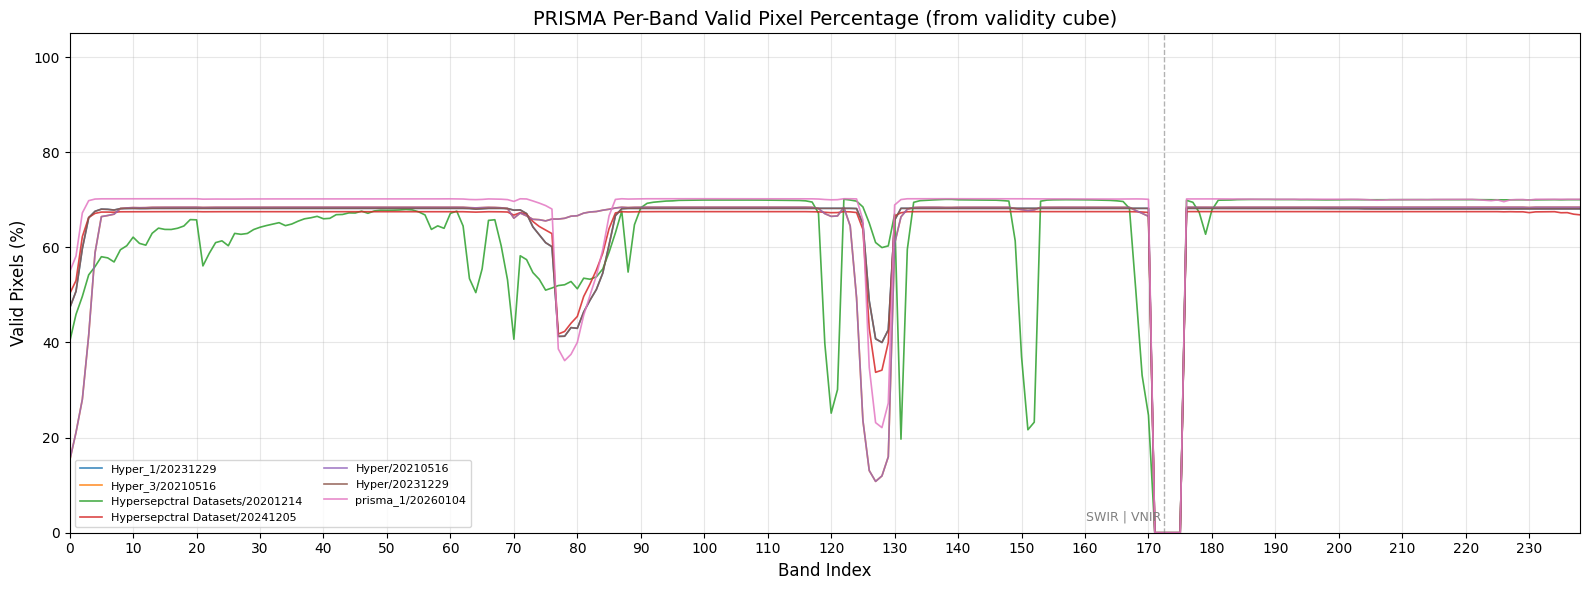

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

cmap = plt.cm.tab10
for i, (label, v) in enumerate(vendables.items()):
    pct = compute_valid_pixel_pct(v)
    band_indices = np.arange(len(pct))
    ax.plot(band_indices, pct, label=label, color=cmap(i % 10), linewidth=1.2, alpha=0.85)

# Mark the SWIR / VNIR boundary
# PRISMA vendable order is SWIR then VNIR; find where family switches
first_vendable = next(iter(vendables.values()))
families = first_vendable.spectral_family_order
for idx in range(1, len(families)):
    if families[idx] != families[idx - 1]:
        ax.axvline(x=idx - 0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6)
        ax.text(idx - 1, 2, f"{families[idx-1].value} | {families[idx].value}",
                fontsize=9, ha="right", va="bottom", color="grey")
        break

ax.set_xlabel("Band Index", fontsize=12)
ax.set_ylabel("Valid Pixels (%)", fontsize=12)
ax.set_title("PRISMA Per-Band Valid Pixel Percentage (from validity cube)", fontsize=14)
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.set_xlim(0, len(pct) - 1)
ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Band number vs. center wavelength

Scatter plot showing the exact wavelength (nm) for each band, colored by SWIR/VNIR detector. Uses data from the first vendable (wavelengths are identical across scenes for the same sensor).

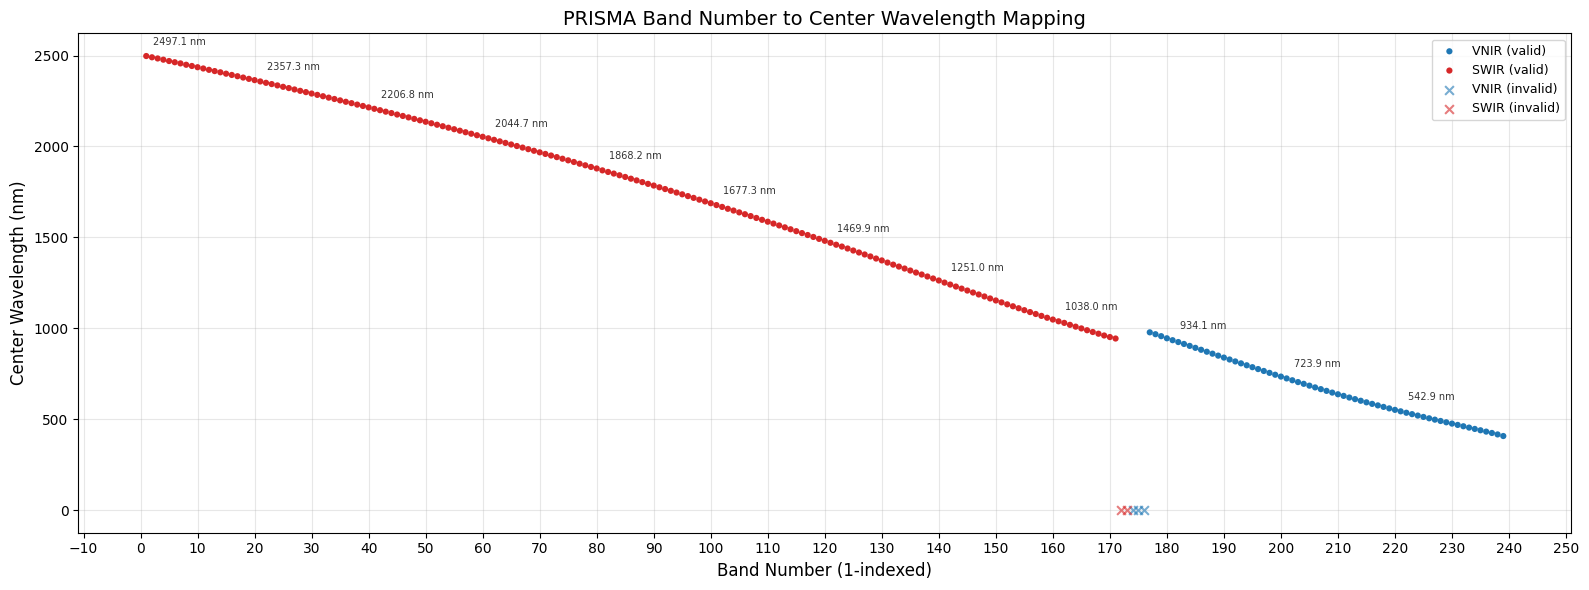

In [12]:
v0 = first_vendable
wavelengths = np.array(v0.band_cw_order)
fwhm = np.array(v0.band_fwhm_order) if v0.band_fwhm_order else None
families = v0.spectral_family_order
band_validity = np.array(v0.band_validity_by_position)
band_numbers = np.arange(1, len(wavelengths) + 1)

is_vnir = np.array([f == SpectralFamily.VNIR for f in families])
is_swir = ~is_vnir

fig, axes = plt.subplots(
    2 if fwhm is not None else 1, 1,
    figsize=(16, 10 if fwhm is not None else 6),
    gridspec_kw={"height_ratios": [3, 1]} if fwhm is not None else None,
)
if fwhm is not None:
    ax1, ax2 = axes
else:
    ax1 = axes

# --- Top panel: wavelength vs band number ---
# Mark invalid bands with X markers
valid_mask = band_validity == 1
invalid_mask = band_validity == 0

# Valid VNIR
m = is_vnir & valid_mask
ax1.scatter(band_numbers[m], wavelengths[m], c="#1f77b4", s=20, label="VNIR (valid)", zorder=3, edgecolors="none")
# Valid SWIR
m = is_swir & valid_mask
ax1.scatter(band_numbers[m], wavelengths[m], c="#d62728", s=20, label="SWIR (valid)", zorder=3, edgecolors="none")
# Invalid VNIR
m = is_vnir & invalid_mask
if m.any():
    ax1.scatter(band_numbers[m], wavelengths[m], c="#1f77b4", s=40, marker="x", label="VNIR (invalid)", zorder=4, alpha=0.6)
# Invalid SWIR
m = is_swir & invalid_mask
if m.any():
    ax1.scatter(band_numbers[m], wavelengths[m], c="#d62728", s=40, marker="x", label="SWIR (invalid)", zorder=4, alpha=0.6)

# Annotate every 20th band with its exact wavelength
for idx in range(0, len(wavelengths), 20):
    ax1.annotate(f"{wavelengths[idx]:.1f} nm",
                 xy=(band_numbers[idx], wavelengths[idx]),
                 xytext=(5, 8), textcoords="offset points",
                 fontsize=7, color="black", alpha=0.8)

ax1.set_xlabel("Band Number (1-indexed)", fontsize=12)
ax1.set_ylabel("Center Wavelength (nm)", fontsize=12)
ax1.set_title("PRISMA Band Number to Center Wavelength Mapping", fontsize=14)
ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.grid(axis="both", alpha=0.3)

# --- Bottom panel: FWHM per band (if available) ---
if fwhm is not None:
    ax2.bar(band_numbers[is_vnir], fwhm[is_vnir], color="#1f77b4", alpha=0.7, label="VNIR FWHM")
    ax2.bar(band_numbers[is_swir], fwhm[is_swir], color="#d62728", alpha=0.7, label="SWIR FWHM")
    ax2.set_xlabel("Band Number (1-indexed)", fontsize=12)
    ax2.set_ylabel("FWHM (nm)", fontsize=12)
    ax2.set_title("Spectral Bandwidth (FWHM) per Band", fontsize=14)
    ax2.legend(fontsize=10)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax2.grid(axis="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Full band wavelength reference table

Every band with its number, center wavelength, FWHM (if available), detector family, and band-level validity flag.

In [11]:
import pandas as pd

rows = []
for i in range(len(wavelengths)):
    row = {
        "Band #": i + 1,
        "Wavelength (nm)": round(wavelengths[i], 2),
        "Detector": "VNIR" if is_vnir[i] else "SWIR",
        "Valid": "Yes" if band_validity[i] == 1 else "No",
    }
    if fwhm is not None:
        row["FWHM (nm)"] = round(fwhm[i], 2)
    rows.append(row)

df_bands = pd.DataFrame(rows)
df_bands.style.set_caption("PRISMA L2D Band Wavelength Reference")

,Band #,Wavelength (nm),Detector,Valid
0,1,2497.120000,SWIR,Yes
1,2,2490.220000,SWIR,Yes
2,3,2483.790000,SWIR,Yes
3,4,2477.050000,SWIR,Yes
4,5,2469.630000,SWIR,Yes
5,6,2463.030000,SWIR,Yes
6,7,2456.590000,SWIR,Yes
7,8,2449.140000,SWIR,Yes
8,9,2442.400000,SWIR,Yes
9,10,2435.540000,SWIR,Yes
